# Surrogate Model Stress Test (qubit_TransmonCross_cap_matrix)
## Gaussian Augmentation + Brute Force Search

We are going to generate thousands of augmented Qiskit Metal parameter sets by adding Gaussian noise based on qiskit metal params of test samples. Then well run them through the surrogate model to predict the capacitance, and save the best
ones to simulate in Ansys HFSS.

## Configuration

In [1]:
from parameters_surrogate import *

## Library

In [2]:
import os, gc, math, time
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.lines import Line2D

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.models import load_model

## Load Dataset & Surrogate Model

In [3]:
def load_scaled_split(kind, split):
    return np.load(f'{DATA_DIR}/npy/{split}_{kind}_encoding_scaled.npy', allow_pickle=True)

X_train = load_scaled_split('linear', 'y_train')
X_val   = load_scaled_split('linear', 'y_val')
X_test  = load_scaled_split('linear', 'y_test')

y_train = load_scaled_split('linear', 'x_train')
y_val   = load_scaled_split('linear', 'x_val')
y_test  = load_scaled_split('linear', 'x_test')

with open('X_names', 'r') as f:
    cap_column_names = f.read().splitlines()

qiskit_param_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()

print(f'Inputs (Qiskit params):  {X_train.shape[1]} columns: {qiskit_param_names}')
print(f'Outputs (Capacitance):   {y_train.shape[1]} columns: {cap_column_names}')
print(f'Training samples: {len(X_train)}, Test samples: {len(X_test)}')

Inputs (Qiskit params):  3 columns: ['design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.cross_length']
Outputs (Capacitance):   6 columns: ['cross_to_ground', 'claw_to_ground', 'cross_to_claw', 'cross_to_cross', 'claw_to_claw', 'ground_to_ground']
Training samples: 1353, Test samples: 291


In [4]:
tf.keras.backend.clear_session()
gc.collect()

chosen_path = 'model/best_keras_model_model2_surrogate.keras'
with tf.device('/CPU:0'):
    surrogate = load_model(chosen_path, compile=False)

print(f'Loaded surrogate: {chosen_path}')
surrogate.summary()

Loaded surrogate: model/best_keras_model_model2_surrogate.keras


I0000 00:00:1773239357.582603  277966 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 607 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:08:00.0, compute capability: 8.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 352)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         2,118 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,526 (13.77 KB)

 Trainable params: 3,526 (13.77 KB)

 Non-trainable params: 0 (0.00 B)

## Load Scalers for Unscaling

In [5]:
# Load all scalers so we can go back and forth between scaled and unscaled
qiskit_scalers = {}
for name in qiskit_param_names:
    qiskit_scalers[name] = joblib.load(f'scalers/scaler_y_linear_{name}.save')

cap_scalers = {}
for name in cap_column_names:
    cap_scalers[name] = joblib.load(f'scalers/scaler_X_linear_{name}.save')

def unscale_qiskit(X_scaled):
    """Unscale Qiskit Metal params from [0,1] back to real values."""
    X_out = X_scaled.copy()
    for j, name in enumerate(qiskit_param_names):
        X_out[:, j] = qiskit_scalers[name].inverse_transform(X_out[:, j:j+1]).ravel()
    return X_out

def scale_qiskit(X_real):
    """Scale real Qiskit Metal params to [0,1]."""
    X_out = X_real.copy()
    for j, name in enumerate(qiskit_param_names):
        X_out[:, j] = qiskit_scalers[name].transform(X_out[:, j:j+1]).ravel()
    return X_out

def unscale_cap(y_scaled):
    """Unscale capacitance predictions back to real values."""
    y_out = y_scaled.copy()
    for j, name in enumerate(cap_column_names):
        y_out[:, j] = cap_scalers[name].inverse_transform(y_out[:, j:j+1]).ravel()
    return y_out

# Quick test
X_test_unscaled = unscale_qiskit(np.asarray(X_test))
print('Unscaled test set param ranges:')
for j, name in enumerate(qiskit_param_names):
    short = name.replace('design_options.', '')
    vals = X_test_unscaled[:, j]
    print(f'  {short:30s}  min={vals.min()}  max={vals.max()}  mean={vals.mean()}')

Unscaled test set param ranges:
  connection_pads.readout.claw_length  min=7e-05  max=0.00037  mean=0.00017103092783505154
  connection_pads.readout.ground_spacing  min=4.1e-06  max=1e-05  mean=7.091752577319587e-06
  cross_length                    min=9e-05  max=0.00042  mean=0.0002902405498281787


## Identify Integer vs Continuous Parameters

We need to know which parameters are integers (like finger_count) so we can
use different noise for those and Gaussian noise for the continuous ones.

In [6]:
#see if all of the training sets are integers for a specific column
X_all_unscaled = unscale_qiskit(np.vstack([X_train, X_val, X_test]).astype('float64'))

is_integer_param = []
integer_unique_vals = {}  
for j, name in enumerate(qiskit_param_names):
    vals = X_all_unscaled[:, j]
    all_integer = np.allclose(vals, np.round(vals))
    is_integer_param.append(all_integer)
    if all_integer:
        integer_unique_vals[j] = sorted(set(np.round(vals).astype(int)))
        print(f'  {name}: INTEGER — unique values: {integer_unique_vals[j]}')
    else:
        print(f'  {name}: CONTINUOUS — range [{vals.min()}, {vals.max()}]')

#figure out the range for each parameter
X_train_unscaled = unscale_qiskit(np.asarray(X_train).astype('float64'))
param_ranges = X_train_unscaled.max(axis=0) - X_train_unscaled.min(axis=0)
print(f'\nParameter ranges: {param_ranges}')

  design_options.connection_pads.readout.claw_length: CONTINUOUS — range [7e-05, 0.00039999999999999996]
  design_options.connection_pads.readout.ground_spacing: CONTINUOUS — range [4.1e-06, 1e-05]
  design_options.cross_length: CONTINUOUS — range [9e-05, 0.00042]

Parameter ranges: [3.3e-04 5.9e-06 3.3e-04]


## Make the gaussians and get the 'noisy' points

Pick some samples from the test set to center the gaussians on, then based on the gaussian associated with each one make 'noisy' copys.

Also here we try many sigma widths to see where the surrogate starts to fail

In [7]:
N_SEED_SAMPLES = 30          #how many real test samples to use as the gaussian centers
N_NOISY_PER_SEED = 200       #how many noisy copies per seed (total_points = N_SEED * N_NOISY)
SIGMA_FRACTIONS = [0.01, 0.02, 0.05, 0.10, 0.20, 0.40]  # fraction of param range to use as sigma

np.random.seed(42) #set this to keep the 'random' selections the same on different trials

#get points from test set to center gaussian on 
seed_indices = np.random.choice(len(X_test), size=min(N_SEED_SAMPLES, len(X_test)), replace=False)
seed_samples_scaled = np.asarray(X_test)[seed_indices]
seed_samples_unscaled = unscale_qiskit(seed_samples_scaled.astype('float64'))
# getting their actual target capacitances to compare to 
seed_caps_scaled = np.asarray(y_test)[seed_indices]  

print(f'Selected {len(seed_indices)} seed samples from test set')
print(f'Will generate {N_NOISY_PER_SEED} noisy copies each at {len(SIGMA_FRACTIONS)} sigma levels')
print(f'Total augmented samples per sigma: {len(seed_indices) * N_NOISY_PER_SEED}')


Selected 30 seed samples from test set
Will generate 200 noisy copies each at 6 sigma levels
Total augmented samples per sigma: 6000


In [8]:
def generate_augmented(seed_unscaled, n_copies, sigma_fraction, param_ranges,
                       is_integer, integer_vals):
    #make noisy copies of a single sample. make sure everything is unscaled
    #everything is continuous so just add Gaussian noise with sigma=sigma_fraction*param_range
    
    n_params = len(seed_unscaled)
    copies = np.tile(seed_unscaled, (n_copies, 1)) 
    
    for j in range(n_params):
        sigma = sigma_fraction * param_ranges[j]
        noise = np.random.normal(0, sigma, size=n_copies)
        copies[:, j] += noise
    
    return copies

## Run each of the samples through the surrogate and time everything

In [9]:
all_results = {}
#go through each sigma
for sigma_frac in SIGMA_FRACTIONS:
    print(f'\n{"-"*70}')
    print(f'Sigma fraction: {sigma_frac} ({sigma_frac*100:.0f}% of param range)')
    print(f'{"-"*70}')

    #store the samples, index number associated with test point for that gaus, 
    #and capacitance associated with the test point
    all_augmented_unscaled = []  
    all_seed_idx = []            
    all_target_caps_scaled = []  
    
    for i, si in enumerate(seed_indices):
        aug_unscaled = generate_augmented(
            seed_samples_unscaled[i], N_NOISY_PER_SEED, sigma_frac,
            param_ranges, is_integer_param, integer_unique_vals)
        all_augmented_unscaled.append(aug_unscaled)
        all_seed_idx.extend([si] * N_NOISY_PER_SEED)
        all_target_caps_scaled.extend([seed_caps_scaled[i]] * N_NOISY_PER_SEED)
    
    all_augmented_unscaled = np.vstack(all_augmented_unscaled)
    all_seed_idx = np.array(all_seed_idx)
    all_target_caps_scaled = np.array(all_target_caps_scaled)
    
    # scale the 'noisy' params back to [0,1] for the surrogate
    all_augmented_scaled = scale_qiskit(all_augmented_unscaled)
    
    #actually run through surrogate and time it
    print(f'Running {len(all_augmented_scaled)} samples through surrogate...')
    t0 = time.time()
    with tf.device('/CPU:0'):
        predicted_caps_scaled = surrogate.predict(all_augmented_scaled.astype('float32'), verbose=0)
    t1 = time.time()
    total_time = t1 - t0
    per_sample_us = (total_time / len(all_augmented_scaled)) * 1e6
    print(f'  Time: {total_time:.3f}s total, {per_sample_us:.1f} μs/sample')
    
    # firnd how close is surrogate prediction to the target capacitance, make an error based on that
    # (MSE per sample between predicted cap and target cap)
    cap_errors = np.mean((predicted_caps_scaled - all_target_caps_scaled) ** 2, axis=1)
    
    # unscale 
    predicted_caps_unscaled = unscale_cap(predicted_caps_scaled)
    target_caps_unscaled = unscale_cap(all_target_caps_scaled)
    
    # Percentage error per capacitance column
    eps = 1e-15
    pct_errors = 100.0 * np.abs(predicted_caps_unscaled - target_caps_unscaled) / (np.abs(target_caps_unscaled) + eps)
    mean_pct_error_per_sample = pct_errors.mean(axis=1)
    
    all_results[sigma_frac] = {
        'augmented_unscaled': all_augmented_unscaled,
        'augmented_scaled': all_augmented_scaled,
        'seed_idx': all_seed_idx,
        'predicted_caps_scaled': predicted_caps_scaled,
        'predicted_caps_unscaled': predicted_caps_unscaled,
        'target_caps_unscaled': target_caps_unscaled,
        'cap_errors_mse': cap_errors,
        'pct_errors': pct_errors,
        'mean_pct_per_sample': mean_pct_error_per_sample,
        'total_time': total_time,
        'per_sample_us': per_sample_us,
    }
    
    print(f'  Mean % error: {mean_pct_error_per_sample.mean():.6f}%')
    print(f'  Median % error: {np.median(mean_pct_error_per_sample):.6f}%')
    print(f'  90th percentile: {np.percentile(mean_pct_error_per_sample, 90):.2f}%')
    print(f'  Max % error: {mean_pct_error_per_sample.max():.2f}%')

/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



----------------------------------------------------------------------
Sigma fraction: 0.01 (1% of param range)
----------------------------------------------------------------------
Running 6000 samples through surrogate...


I0000 00:00:1773239357.920281  278306 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Time: 0.520s total, 86.7 μs/sample
  Mean % error: 1.298996%
  Median % error: 1.113493%
  90th percentile: 2.41%
  Max % error: 8.66%

----------------------------------------------------------------------
Sigma fraction: 0.02 (2% of param range)
----------------------------------------------------------------------
Running 6000 samples through surrogate...


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


...

  Time: 0.311s total, 51.9 μs/sample
  Mean % error: 12.619511%
  Median % error: 10.725264%
  90th percentile: 23.59%
  Max % error: 79.50%

----------------------------------------------------------------------
Sigma fraction: 0.2 (20% of param range)
----------------------------------------------------------------------
Running 6000 samples through surrogate...


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


  Time: 0.290s total, 48.4 μs/sample
  Mean % error: 25.936001%
  Median % error: 22.101703%
  90th percentile: 48.15%
  Max % error: 165.69%

----------------------------------------------------------------------
Sigma fraction: 0.4 (40% of param range)
----------------------------------------------------------------------
Running 6000 samples through surrogate...


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


  Time: 0.328s total, 54.7 μs/sample
  Mean % error: 53.522250%
  Median % error: 44.221356%
  90th percentile: 102.83%
  Max % error: 365.53%


## Visualize the results

First see how 'accuracy' scales with sigma, although this isnt really accurate because it compares values far away from the center points to the ones close, so we expect points from the higher sigma gaussian to do worse because they are further from the center point that we compare the capacitance values to

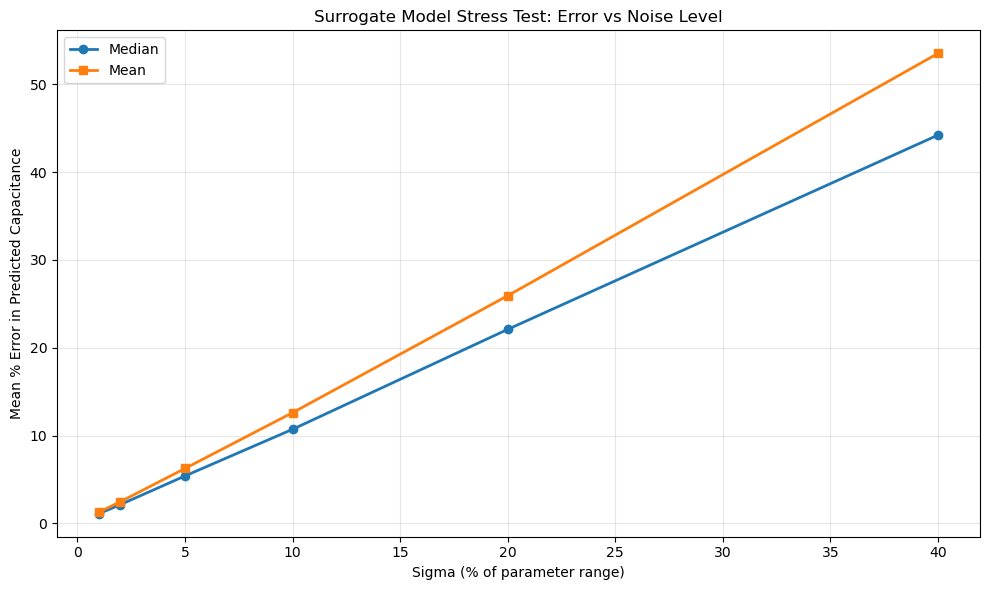

In [10]:
#plot error vs sigma to see where the surrogate starts to fail
sigmas = sorted(all_results.keys())
medians = [np.median(all_results[s]['mean_pct_per_sample']) for s in sigmas]
means = [all_results[s]['mean_pct_per_sample'].mean() for s in sigmas]
maxes = [all_results[s]['mean_pct_per_sample'].max() for s in sigmas]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot([s*100 for s in sigmas], medians, 'o-', label='Median', linewidth=2)
ax.plot([s*100 for s in sigmas], means, 's-', label='Mean', linewidth=2)
ax.set_xlabel('Sigma (% of parameter range)')
ax.set_ylabel('Mean % Error in Predicted Capacitance')
ax.set_title('Surrogate Model Stress Test: Error vs Noise Level')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/surrogate_stress_test_error_vs_sigma.pdf')
plt.show()

In [11]:
# timing summary
total_samples = sum(len(all_results[s]['augmented_scaled']) for s in sigmas)
total_time = sum(all_results[s]['total_time'] for s in sigmas)
avg_us = (total_time / total_samples) * 1e6

print(f'Total samples across all sigmas: {total_samples}')
print(f'Total surrogate inference time:  {total_time:.3f}s')
print(f'Average speed:                   {avg_us:.1f} μs/sample')
print()
print('For comparison, a single Ansys HFSS simulation takes ~10 minutes.')

Total samples across all sigmas: 36000
Total surrogate inference time:  2.065s
Average speed:                   57.4 μs/sample

For comparison, a single Ansys HFSS simulation takes ~10 minutes.


## Pick Best Candidates for Ansys Validation

In [12]:
# For each sigma level, pick 10 RANDOM candidates (not best — we want unbiased samples)

N_RANDOM = 10  # how many random candidates to pick per sigma

random_candidates = {}
for sigma_frac in SIGMA_FRACTIONS:
    r = all_results[sigma_frac]
    # Pick random indices instead of sorting by error
    rand_idx = np.random.choice(len(r['cap_errors_mse']), size=N_RANDOM, replace=False)
    
    random_candidates[sigma_frac] = {
        'indices': rand_idx,
        'params_unscaled': r['augmented_unscaled'][rand_idx],
        'params_scaled': r['augmented_scaled'][rand_idx],
        'predicted_caps_unscaled': r['predicted_caps_unscaled'][rand_idx],
        'target_caps_unscaled': r['target_caps_unscaled'][rand_idx],
        'mean_pct_error': r['mean_pct_per_sample'][rand_idx],
        'seed_idx': r['seed_idx'][rand_idx],
    }

print(f'Selected {N_RANDOM} random candidates per sigma level ({N_RANDOM * len(SIGMA_FRACTIONS)} total)')


Selected 10 random candidates per sigma level (60 total)


In [13]:
# Print the random candidates for each sigma level
for sigma_frac in SIGMA_FRACTIONS:
    rc = random_candidates[sigma_frac]
    print(f'\n{"-"*80}')
    print(f'RANDOM {len(rc["indices"])} CANDIDATES — Sigma = {sigma_frac*100:.0f}% of param range')
    print(f'{"-"*80}')
    
    for rank in range(len(rc['indices'])):
        print(f'\n--- Sample {rank+1} (mean cap error: {rc["mean_pct_error"][rank]:.2f}%) ---')
        print(f'  Seed test sample index: {rc["seed_idx"][rank]}')
        
        print(f'  Qiskit Metal params (for Ansys simulation):')
        for j, name in enumerate(qiskit_param_names):
            short = name.replace('design_options.', '')
            val = rc['params_unscaled'][rank, j]
            if is_integer_param[j]:
                print(f'    {short:30s}  {int(round(val))}')
            else:
                print(f'    {short:30s}  {val}')
        
        print(f'  Surrogate predicted capacitance:')
        for j, name in enumerate(cap_column_names):
            short = name.split('.')[-1] if '.' in name else name
            print(f'    {short:30s}  {rc["predicted_caps_unscaled"][rank, j]:.6e}')
        
        print(f'  Target capacitance (from seed test sample):')
        for j, name in enumerate(cap_column_names):
            short = name.split('.')[-1] if '.' in name else name
            print(f'    {short:30s}  {rc["target_caps_unscaled"][rank, j]:.6e}')



--------------------------------------------------------------------------------
RANDOM 10 CANDIDATES — Sigma = 1% of param range
--------------------------------------------------------------------------------

--- Sample 1 (mean cap error: 2.39%) ---
  Seed test sample index: 9
  Qiskit Metal params (for Ansys simulation):
    connection_pads.readout.claw_length  0.00011405504011152333
    connection_pads.readout.ground_spacing  9.070295721709837e-06
    cross_length                    0.000253325016253117
  Surrogate predicted capacitance:
    cross_to_ground                 1.329944e+02
    claw_to_ground                  7.691602e+01
    cross_to_claw                   2.909602e+00
    cross_to_cross                  1.329829e+02
    claw_to_claw                    8.020699e+01
    ground_to_ground                2.668457e+02
  Target capacitance (from seed test sample):
    cross_to_ground                 1.314099e+02
    claw_to_ground                  7.959486e+01
    cross_to

## Exporting Best Candidates for Firas to Simulate

In [14]:
# Save a CSV with all the random candidates for Firas to simulate in Ansys
export_rows = []
for sigma_frac in SIGMA_FRACTIONS:
    rc = random_candidates[sigma_frac]
    for rank in range(len(rc['indices'])):
        row = {
            'sigma_for_gauss': sigma_frac * 100,
            'sample_number': rank + 1,
            'test_set_index_as_gauss_mean': rc['seed_idx'][rank],
            'avg_percent_err_in_cap': rc['mean_pct_error'][rank],
            'surrogate_inference_us': all_results[sigma_frac]['per_sample_us'],
        }
        #qiskit metal params
        for j, name in enumerate(qiskit_param_names):
            val = rc['params_unscaled'][rank, j]
            row[f'{name}'] = val
        #surrogate predicted caps
        for j, name in enumerate(cap_column_names):
            short = name.split('.')[-1] if '.' in name else name
            row[f'surrogate_pred_{short}'] = rc['predicted_caps_unscaled'][rank, j]
        #target caps
        for j, name in enumerate(cap_column_names):
            short = name.split('.')[-1] if '.' in name else name
            row[f'target_{short}'] = rc['target_caps_unscaled'][rank, j]
        export_rows.append(row)

df_export = pd.DataFrame(export_rows)
csv_path = 'random_candidates_for_ansys_validation.csv'
df_export.to_csv(csv_path, index=False, float_format='%.6g')
print(f'Saved {len(df_export)} random candidates to {csv_path} ({N_RANDOM} per sigma x {len(SIGMA_FRACTIONS)} sigmas)')
display(df_export)


Saved 60 random candidates to random_candidates_for_ansys_validation.csv (10 per sigma x 6 sigmas)


,sigma_for_gauss,sample_number,test_set_index_as_gauss_mean,avg_percent_err_in_cap,surrogate_inference_us,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length,surrogate_pred_cross_to_ground,surrogate_pred_claw_to_ground,surrogate_pred_cross_to_claw,surrogate_pred_cross_to_cross,surrogate_pred_claw_to_claw,surrogate_pred_ground_to_ground,target_cross_to_ground,target_claw_to_ground,target_cross_to_claw,target_cross_to_cross,target_claw_to_claw,target_ground_to_ground
0,1.0,1,9,2.394404,86.725553,0.000114,9.070296e-06,0.000253,132.994354,76.916016,2.909602,132.982864,80.206993,266.845673,131.40994,79.59486,3.06183,131.40994,83.01717,267.49113
1,1.0,2,5,3.197385,86.725553,0.000092,4.993016e-06,0.000252,132.160873,66.191238,2.921396,132.128601,69.453430,255.077408,130.73017,69.00516,3.18581,130.73017,72.53547,256.08539
2,1.0,3,84,2.867616,86.725553,0.000094,4.081158e-06,0.000174,84.588448,63.643635,3.221884,84.610870,67.286041,197.213440,87.31921,64.65447,3.40172,87.31921,68.46876,202.06141
3,1.0,4,109,0.907724,86.725553,0.000252,4.068387e-06,0.000304,150.227219,116.128616,8.779753,150.191467,125.461372,327.343964,147.95729,115.45089,8.75973,147.95729,124.79418,323.93644
4,1.0,5,75,0.191071,86.725553,0.000280,4.106575e-06,0.000370,186.389374,125.919640,9.486590,186.386215,135.954788,379.394043,185.92649,125.81046,9.45144,185.92649,135.86189,378.92744
5,1.0,6,5,0.393124,86.725553,0.000099,4.991485e-06,0.000250,130.998917,68.737625,3.150722,130.968307,72.239273,256.273773,130.73017,69.00516,3.18581,130.73017,72.53547,256.08539
6,1.0,7,277,0.251195,86.725553,0.000310,4.067914e-06,0.000409,213.757523,140.675049,10.864766,213.710754,152.082535,425.067719,214.56612,140.96612,10.87649,214.56612,152.38227,426.00789
7,1.0,8,176,0.966205,86.725553,0.000117,4.978707e-06,0.000179,90.115814,74.677475,3.999708,90.121841,79.148544,214.541901,90.44148,75.74832,4.06477,90.44148,80.30351,215.90461
8,1.0,9,279,1.429251,86.725553,0.000136,4.098091e-06,0.000261,130.543884,77.736076,4.457555,130.533905,82.607246,265.439331,130.02149,79.16881,4.62872,130.02149,84.15886,266.58122
9,1.0,10,101,1.125609,86.725553,0.000240,1.007337e-05,0.000409,216.460205,122.354813,5.785751,216.535309,128.498413,410.007446,219.69830,123.22641,5.86327,219.69830,129.52221,414.23350


In [15]:
# === 20 linearly spaced samples along a single Gaussian at 40% sigma ===
# Build the sweep around the CENTER of the full parameter box instead of around
# one random seed sample. This keeps the Gaussian bubble centered in the full
# parameter space and avoids biasing the line sweep toward one side.
#
# We still attach the nearest real test-set target capacitance for reference,
# but the Gaussian mean itself is the global parameter-space midpoint.

np.random.seed(123)

sigma_frac_linear = 0.20

# Use the midpoint of the full observed parameter box as the Gaussian mean
param_mins = X_all_unscaled.min(axis=0)
param_maxs = X_all_unscaled.max(axis=0)
param_ranges = param_maxs - param_mins
param_midpoint_unscaled = 0.5 * (param_mins + param_maxs)
linear_seed_unscaled = param_midpoint_unscaled.copy()

X_test_unscaled_all = unscale_qiskit(np.asarray(X_test).astype('float64'))
safe_param_ranges = np.where(param_ranges == 0, 1.0, param_ranges)

# Keep a nearby real test sample only as a reference target cap in the CSV
X_test_unscaled_all = unscale_qiskit(np.asarray(X_test).astype('float64'))
safe_param_ranges = np.where(param_ranges == 0, 1.0, param_ranges)
dist_to_midpoint = np.linalg.norm((X_test_unscaled_all - linear_seed_unscaled) / safe_param_ranges, axis=1)
linear_seed_idx = int(np.argmin(dist_to_midpoint))
linear_seed_cap_scaled = np.asarray(y_test)[linear_seed_idx]

sigmas_per_param = sigma_frac_linear * param_ranges

# Pick a random direction in the full n-dimensional parameter space
direction = np.random.randn(len(qiskit_param_names))
direction = direction / np.linalg.norm(direction)  # unit vector

# Scale direction by each param's sigma so we move proportionally
scaled_direction = direction * sigmas_per_param

# Find the largest symmetric sweep that stays inside the full parameter bounds
max_t_pos = []
max_t_neg = []
for j in range(len(qiskit_param_names)):
    step = scaled_direction[j]
    if np.isclose(step, 0.0):
        max_t_pos.append(np.inf)
        max_t_neg.append(np.inf)
    elif step > 0:
        max_t_pos.append((param_maxs[j] - linear_seed_unscaled[j]) / step)
        max_t_neg.append((linear_seed_unscaled[j] - param_mins[j]) / step)
    else:
        max_t_pos.append((linear_seed_unscaled[j] - param_mins[j]) / (-step))
        max_t_neg.append((param_maxs[j] - linear_seed_unscaled[j]) / (-step))

t_extent = min(2.0, float(np.min(max_t_pos)), float(np.min(max_t_neg)))

# 20 linearly spaced points from -t_extent*sigma to +t_extent*sigma along this direction
t_values = np.linspace(-t_extent, t_extent, 20)
linear_samples_unscaled = np.array([linear_seed_unscaled + t * scaled_direction for t in t_values])

# Numerical safety: keep every point inside the observed parameter box
linear_samples_unscaled = np.clip(linear_samples_unscaled, param_mins, param_maxs)

# Scale and run through surrogate
linear_samples_scaled = scale_qiskit(linear_samples_unscaled)
with tf.device('/CPU:0'):
    linear_pred_caps_scaled = surrogate.predict(linear_samples_scaled.astype('float32'), verbose=0)
linear_pred_caps_unscaled = unscale_cap(linear_pred_caps_scaled)

# Reference target cap (from the nearest real test sample to the global midpoint)
target_cap_unscaled = unscale_cap(np.array([linear_seed_cap_scaled]))[0]

# Build CSV
export_rows = []
for i in range(20):
    row = {
        'sample_number': i + 1,
        'sigma_multiplier': t_values[i],
        'sigma_for_gauss': sigma_frac_linear * 100,
        'test_set_index_as_gauss_mean': -1,
        'nearest_test_set_index_for_target': linear_seed_idx,
    }
    # Qiskit Metal params
    for j, name in enumerate(qiskit_param_names):
        row[f'{name}'] = linear_samples_unscaled[i, j]
    # Surrogate predicted caps
    for j, name in enumerate(cap_column_names):
        short = name.split('.')[-1] if '.' in name else name
        row[f'surrogate_pred_{short}'] = linear_pred_caps_unscaled[i, j]
    # Target caps
    for j, name in enumerate(cap_column_names):
        short = name.split('.')[-1] if '.' in name else name
        row[f'target_{short}'] = target_cap_unscaled[j]
    export_rows.append(row)

df_linear = pd.DataFrame(export_rows)
csv_path = 'linear_sweep_20pct_sigma_for_ansys.csv'
df_linear.to_csv(csv_path, index=False, float_format='%.6g')
print(f'Saved {len(df_linear)} linearly spaced samples to {csv_path}')
print('Gaussian mean: global midpoint of the full parameter box')
print(f'Nearest test-set index used only for target caps: {linear_seed_idx}')
print(f'Direction walks from {-t_extent:.3f}σ to +{t_extent:.3f}σ along a random direction in param space')
print(f'Nominal σ = 20% of each param range')
print()
print('sigma_multiplier column: 0.0 = at the global midpoint')
display(df_linear)


Saved 20 linearly spaced samples to linear_sweep_20pct_sigma_for_ansys.csv
Gaussian mean: global midpoint of the full parameter box
Nearest test-set index used only for target caps: 282
Direction walks from -2.000σ to +2.000σ along a random direction in param space
Nominal σ = 20% of each param range

sigma_multiplier column: 0.0 = at the global midpoint


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


,sample_number,sigma_multiplier,sigma_for_gauss,test_set_index_as_gauss_mean,nearest_test_set_index_for_target,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length,surrogate_pred_cross_to_ground,surrogate_pred_claw_to_ground,surrogate_pred_cross_to_claw,surrogate_pred_cross_to_cross,surrogate_pred_claw_to_claw,surrogate_pred_ground_to_ground,target_cross_to_ground,target_claw_to_ground,target_cross_to_claw,target_cross_to_cross,target_claw_to_claw,target_ground_to_ground
0,1,-2.000000,20.0,-1,282,0.00033,0.000005,0.000230,106.522148,146.367966,15.490218,105.839142,162.062561,306.068268,126.26781,110.51621,7.85452,126.26781,118.95233,292.6631
1,2,-1.789474,20.0,-1,282,0.00032,0.000006,0.000233,109.257408,143.331924,14.626034,108.556000,158.186020,306.111725,126.26781,110.51621,7.85452,126.26781,118.95233,292.6631
2,3,-1.578947,20.0,-1,282,0.00031,0.000006,0.000235,111.881042,140.324448,13.765305,111.194191,154.356949,306.119415,126.26781,110.51621,7.85452,126.26781,118.95233,292.6631
3,4,-1.368421,20.0,-1,282,0.00030,0.000006,0.000238,114.504654,137.316940,12.904572,113.832375,150.527908,306.127075,126.26781,110.51621,7.85452,126.26781,118.95233,292.6631
4,5,-1.157895,20.0,-1,282,0.00029,0.000006,0.000241,117.036263,134.321198,12.048614,116.401085,146.743896,306.070312,126.26781,110.51621,7.85452,126.26781,118.95233,292.6631
5,6,-0.947368,20.0,-1,282,0.00028,0.000006,0.000243,119.424316,131.292999,11.222136,118.947906,142.954086,305.768677,126.26781,110.51621,7.85452,126.26781,118.95233,292.6631
6,7,-0.736842,20.0,-1,282,0.00027,0.000006,0.000246,121.812401,128.264801,10.395655,121.494766,139.164307,305.467041,126.26781,110.51621,7.85452,126.26781,118.95233,292.6631
7,8,-0.526316,20.0,-1,282,0.00026,0.000007,0.000248,124.200462,125.236595,9.569178,124.041603,135.374512,305.165405,126.26781,110.51621,7.85452,126.26781,118.95233,292.6631
8,9,-0.315789,20.0,-1,282,0.00025,0.000007,0.000251,126.450966,122.275925,8.766771,126.379311,131.647125,304.774811,126.26781,110.51621,7.85452,126.26781,118.95233,292.6631
9,10,-0.105263,20.0,-1,282,0.00024,0.000007,0.000254,128.554688,119.387360,7.990056,128.493790,127.986404,304.289093,126.26781,110.51621,7.85452,126.26781,118.95233,292.6631


In [16]:
# Summary of what was exported
print(f'Total candidates for Firas: {len(df_export)}')
print(f'  {N_RANDOM} random samples per sigma level')
print(f'  Sigma levels: {[f"{s*100:.0f}%" for s in SIGMA_FRACTIONS]}')
print(f'\nThese are RANDOM samples (not cherry-picked best ones)')
print(f'so the Ansys results will give an unbiased picture of surrogate accuracy.')


Total candidates for Firas: 60
  10 random samples per sigma level
  Sigma levels: ['1%', '2%', '5%', '10%', '20%', '40%']

These are RANDOM samples (not cherry-picked best ones)
so the Ansys results will give an unbiased picture of surrogate accuracy.


## Per-Sigma Scatter Plots

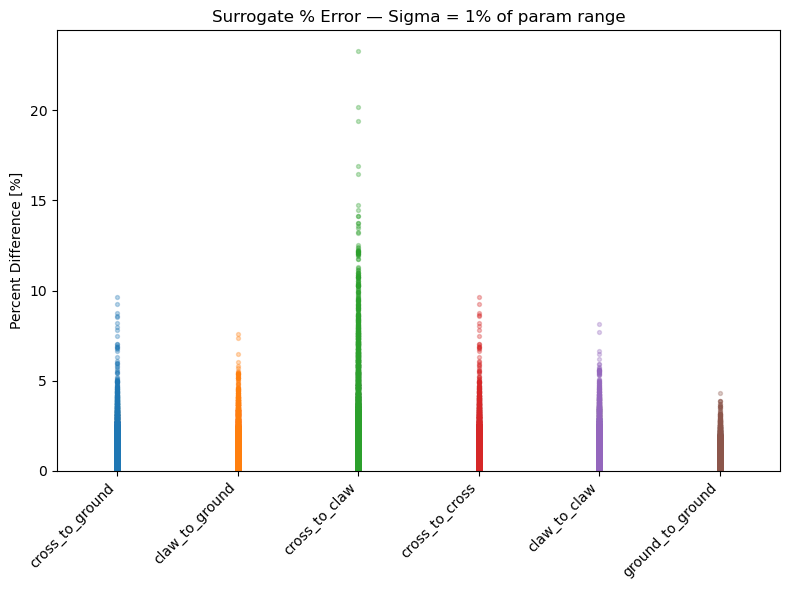

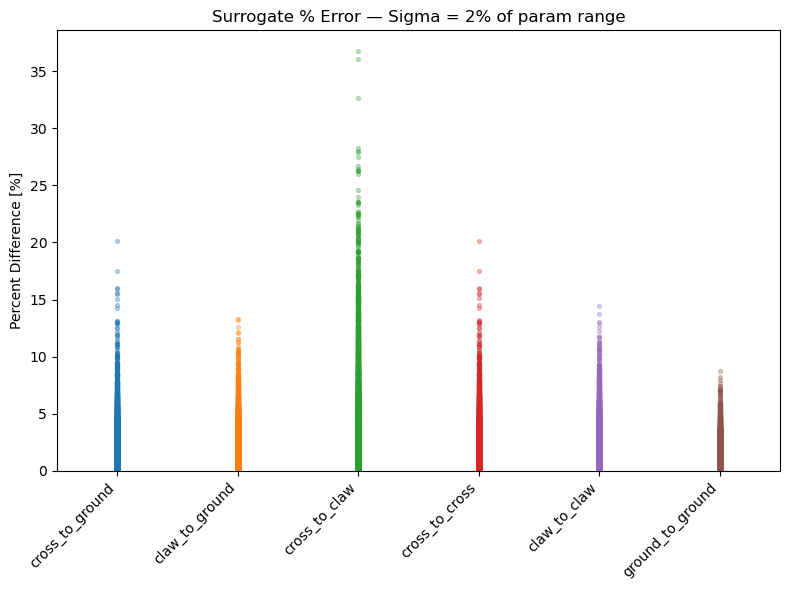

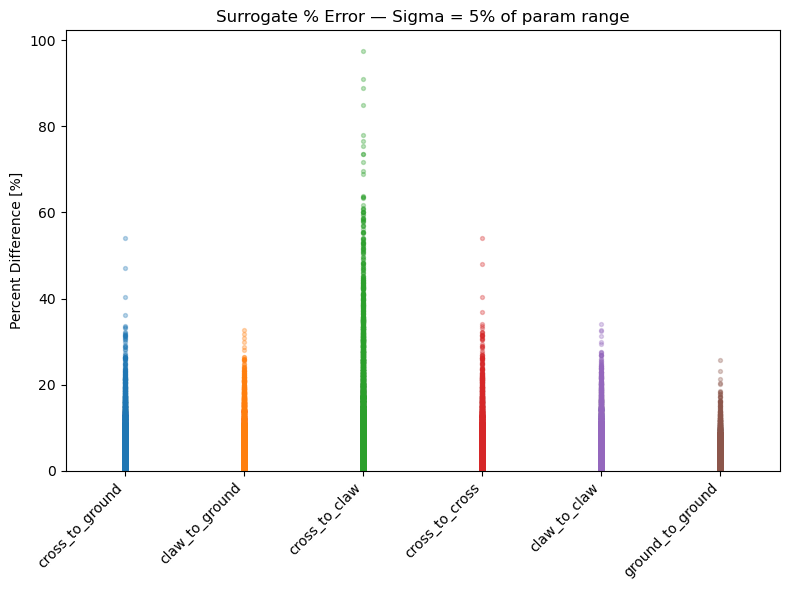

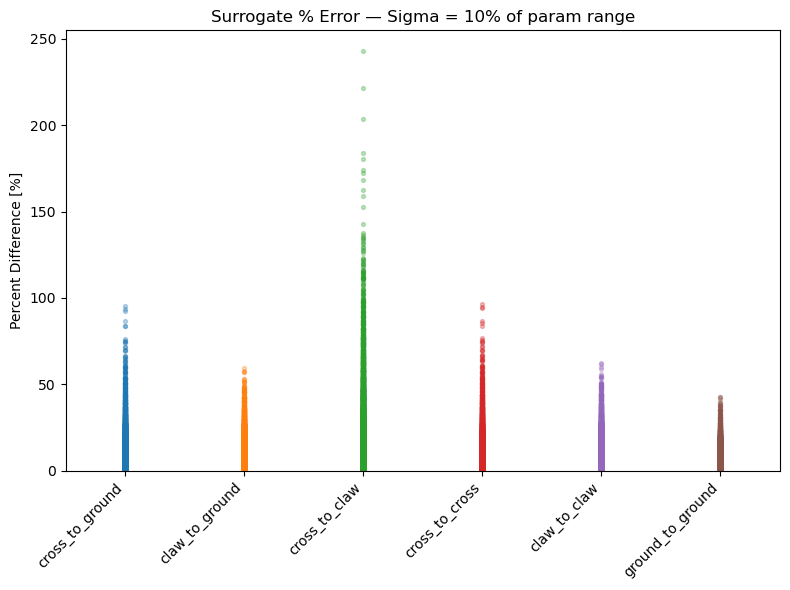

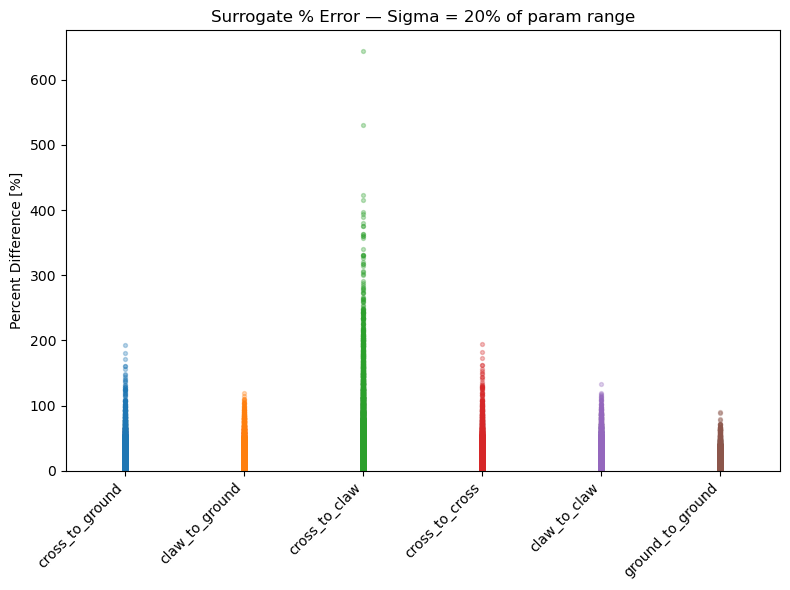

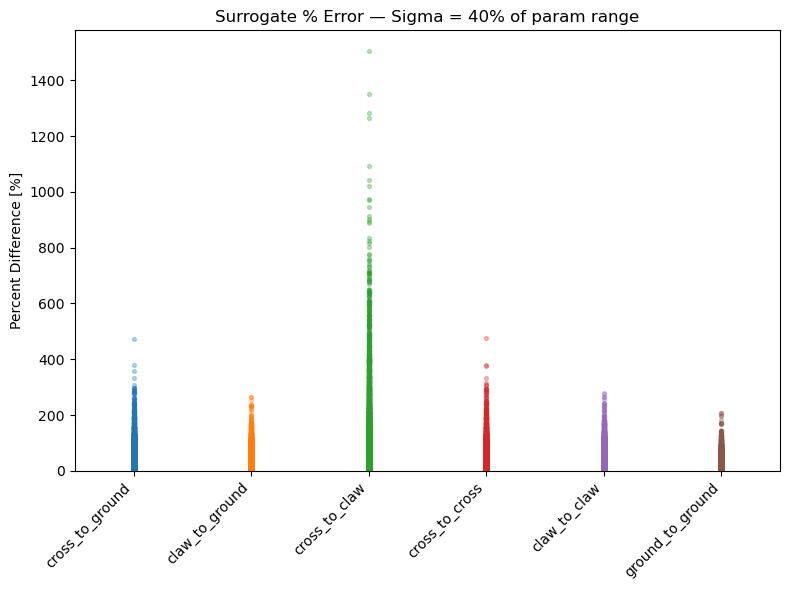

In [17]:
# for each sigma, scatter plot of % error per capacitance column
short_cap_names = [c.split('.')[-1] if '.' in c else c for c in cap_column_names]
n_caps = len(cap_column_names)

for sigma_frac in SIGMA_FRACTIONS:
    r = all_results[sigma_frac]
    fig, ax = plt.subplots(figsize=(8, 6))
    for j in range(n_caps):
        col_pct = r['pct_errors'][:, j]
        ax.scatter(np.full(len(col_pct), j), col_pct, s=8, alpha=0.3)
    ax.set_xticks(range(n_caps))
    ax.set_xticklabels(short_cap_names, rotation=45, ha='right')
    ax.set_ylabel('Percent Difference [%]')
    ax.set_title(f'Surrogate % Error — Sigma = {sigma_frac*100:.0f}% of param range')
    ax.set_ylim(0, None)
    ax.margins(y=0)
    ax.set_xlim(-0.5, n_caps - 0.5)
    plt.tight_layout()
    plt.savefig(f'plots/surrogate_stress_sigma_{int(sigma_frac*100)}_pct_scatter.pdf')
    plt.show()

## 
plot in 3d the gaussians to get a feeling for their shapes/ranges

Top 4 test vals by frequency in random candidates:
  Seed test idx 277: 7 random candidates
  Seed test idx 176: 4 random candidates
  Seed test idx 5: 3 random candidates
  Seed test idx 84: 3 random candidates


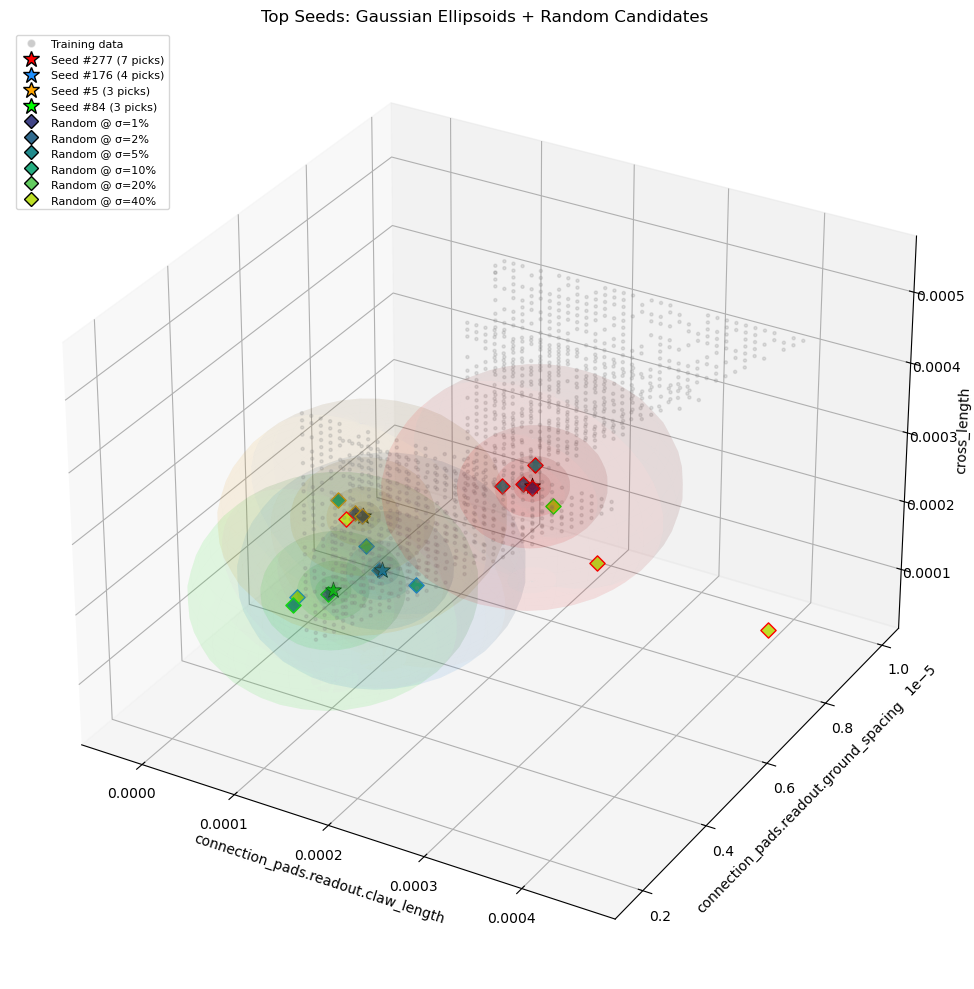

In [18]:
cont_indices = [j for j in range(len(qiskit_param_names)) if not is_integer_param[j]]
if len(cont_indices) >= 3:
    p0, p1, p2 = cont_indices[0], cont_indices[1], cont_indices[2]
else:
    p0, p1, p2 = 0, 1, 2

axis_names = [
    qiskit_param_names[p0].replace('design_options.', ''),
    qiskit_param_names[p1].replace('design_options.', ''),
    qiskit_param_names[p2].replace('design_options.', ''),
]

def draw_ellipsoid(ax, center, sigmas, color, alpha=0.15):
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 20)
    x = center[0] + sigmas[0] * np.outer(np.cos(u), np.sin(v))
    y = center[1] + sigmas[1] * np.outer(np.sin(u), np.sin(v))
    z = center[2] + sigmas[2] * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(x, y, z, color=color, alpha=alpha, linewidth=0)

colors_sigma = plt.cm.viridis(np.linspace(0.2, 0.9, len(SIGMA_FRACTIONS)))
seed_idx_to_pos = {si: i for i, si in enumerate(seed_indices)}

# count how many of the random 10 per sigma came from each test value
seed_counts = Counter()
seed_to_candidates = {}
for sigma_frac in SIGMA_FRACTIONS:
    rc = random_candidates[sigma_frac]
    for rank in range(len(rc['indices'])):
        sid = rc['seed_idx'][rank]
        seed_counts[sid] += 1
        if sid not in seed_to_candidates:
            seed_to_candidates[sid] = []
        seed_to_candidates[sid].append({
            'sigma_frac': sigma_frac,
            'rank': rank,
            'params': rc['params_unscaled'][rank],
        })

# pick top 4 test values to plot gaussians around
top_4_seeds = [sid for sid, count in seed_counts.most_common(4)]
print('Top 4 test vals by frequency in random candidates:')
for sid in top_4_seeds:
    print(f'  Seed test idx {sid}: {seed_counts[sid]} random candidates')

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# training data
ax.scatter(
    X_train_unscaled[:, p0],
    X_train_unscaled[:, p1],
    X_train_unscaled[:, p2],
    c='gray', s=5, alpha=0.2, label='Training data'
)

seed_colors = ['red', 'dodgerblue', 'orange', 'lime']

for seed_rank, top_seed in enumerate(top_4_seeds):
    pos = seed_idx_to_pos[top_seed]
    sc = seed_colors[seed_rank % len(seed_colors)]

    # seed test value
    ax.scatter(
        seed_samples_unscaled[pos, p0],
        seed_samples_unscaled[pos, p1],
        seed_samples_unscaled[pos, p2],
        c=sc, s=150, marker='*', edgecolors='black', linewidths=0.5, zorder=5
    )

    # ellipsoids at each sigma
    center = [
        seed_samples_unscaled[pos, p0],
        seed_samples_unscaled[pos, p1],
        seed_samples_unscaled[pos, p2]
    ]
    for si_frac, sigma_frac in enumerate(SIGMA_FRACTIONS):
        sigmas_3d = [
            sigma_frac * param_ranges[p0],
            sigma_frac * param_ranges[p1],
            sigma_frac * param_ranges[p2]
        ]
        draw_ellipsoid(ax, center, sigmas_3d, sc, alpha=0.05)

    # random candidates from this seed, color-coded by sigma
    for entry in seed_to_candidates[top_seed]:
        si_frac = SIGMA_FRACTIONS.index(entry['sigma_frac'])
        params = entry['params']
        ax.scatter(
            params[p0], params[p1], params[p2],
            c=[colors_sigma[si_frac]], s=60, marker='D',
            edgecolors=sc, linewidths=1.0, zorder=10
        )

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=6, alpha=0.4, label='Training data'),
]

for sid, sc in zip(top_4_seeds, seed_colors):
    legend_elements.append(
        Line2D([0], [0], marker='*', color='w', markerfacecolor=sc,
               markeredgecolor='black', markersize=12,
               label=f'Seed #{sid} ({seed_counts[sid]} picks)')
    )

for si_frac, sigma_frac in enumerate(SIGMA_FRACTIONS):
    legend_elements.append(
        Line2D([0], [0], marker='D', color='w',
               markerfacecolor=colors_sigma[si_frac],
               markeredgecolor='black', markersize=7,
               label=f'Random @ σ={sigma_frac*100:.0f}%')
    )

ax.set_xlabel(axis_names[0])
ax.set_ylabel(axis_names[1])
ax.set_zlabel(axis_names[2])
ax.set_title('Top Seeds: Gaussian Ellipsoids + Random Candidates')
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('plots/surrogate_stress_3d_top_seeds_random.pdf')
plt.show()

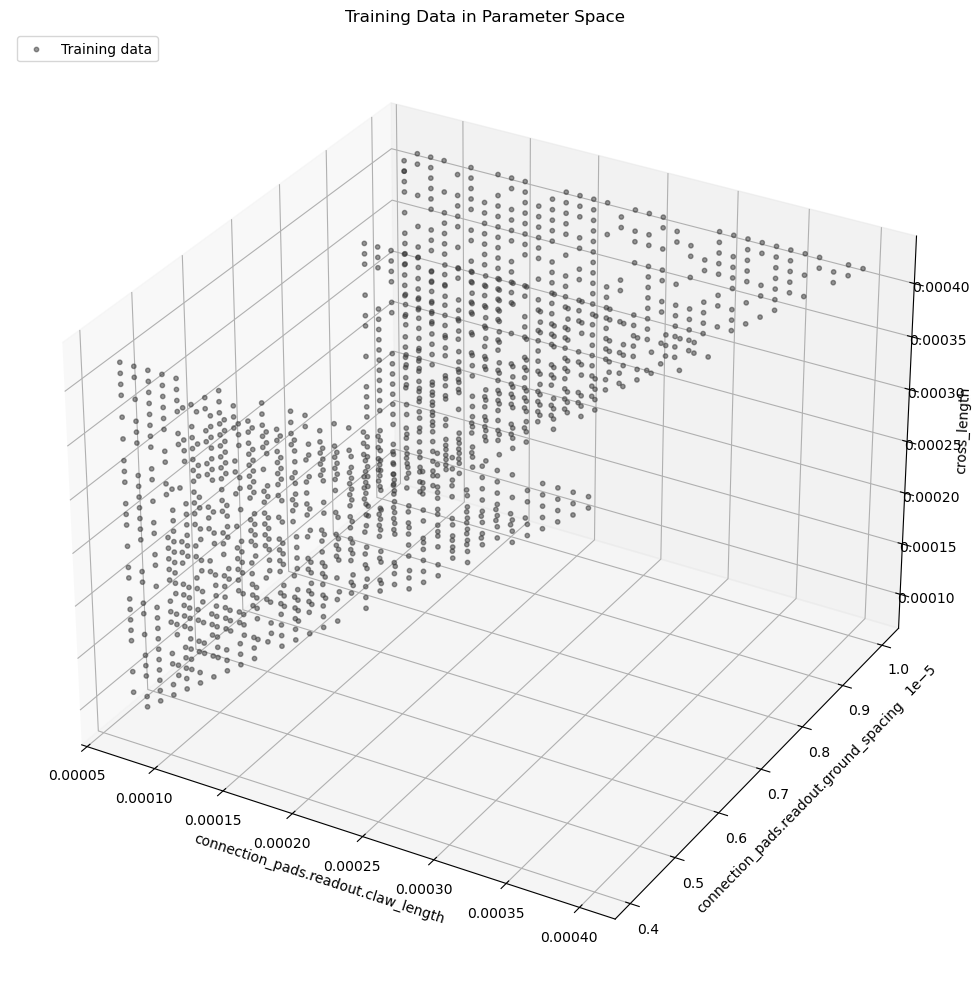

In [19]:
cont_indices = [j for j in range(len(qiskit_param_names)) if not is_integer_param[j]]
if len(cont_indices) >= 3:
    p0, p1, p2 = cont_indices[0], cont_indices[1], cont_indices[2]
else:
    p0, p1, p2 = 0, 1, 2

axis_names = [
    qiskit_param_names[p0].replace('design_options.', ''),
    qiskit_param_names[p1].replace('design_options.', ''),
    qiskit_param_names[p2].replace('design_options.', ''),
]

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_train_unscaled[:, p0], X_train_unscaled[:, p1], X_train_unscaled[:, p2],
           c='#333333', s=10, alpha=0.5, label='Training data')

ax.set_xlabel(axis_names[0])
ax.set_ylabel(axis_names[1])
ax.set_zlabel(axis_names[2])
ax.set_title('Training Data in Parameter Space')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('plots/training_data_3d.pdf')
plt.show()

# Ansys results

In [20]:
df = pd.read_csv('random_candidates_for_ansys_validation-with_Ansys_results.csv')

    
cap_names = ['cross_to_ground', 'claw_to_ground', 'cross_to_claw',
             'cross_to_cross', 'claw_to_claw', 'ground_to_ground']
# Force ansys columns to numeric (coerce any non-numeric entries to NaN)
for cap in cap_names:
    df[f'ansys_{cap}'] = pd.to_numeric(df[f'ansys_{cap}'], errors='coerce')

eps = 1e-15

# Compute % errors: Ansys vs surrogate, and Ansys vs target
for cap in cap_names:
    df[f'pct_ansys_vs_surrogate_{cap}'] = 100 * abs(df[f'ansys_{cap}'] - df[f'surrogate_pred_{cap}']) / (abs(df[f'ansys_{cap}']) + eps)
    df[f'pct_ansys_vs_target_{cap}'] = 100 * abs(df[f'ansys_{cap}'] - df[f'target_{cap}']) / (abs(df[f'ansys_{cap}']) + eps)

# Mean % error across all cap columns per row
df['mean_pct_ansys_vs_surrogate'] = df[[f'pct_ansys_vs_surrogate_{c}' for c in cap_names]].mean(axis=1)
df['mean_pct_ansys_vs_target'] = df[[f'pct_ansys_vs_target_{c}' for c in cap_names]].mean(axis=1)

sigmas = sorted(df['sigma_for_gauss'].unique())

/home/olivias/.conda/envs/cryo-modelling-env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/olivias/.conda/envs/cryo-modelling-env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


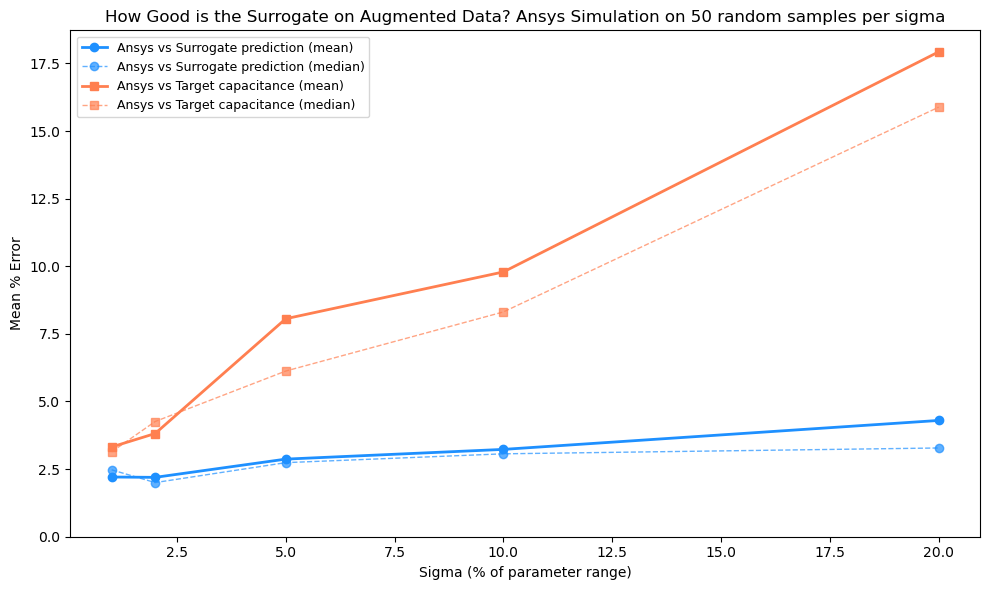

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, col, marker, color in [
    ('Ansys vs Surrogate prediction', 'mean_pct_ansys_vs_surrogate', 'o', 'dodgerblue'),
    ('Ansys vs Target capacitance', 'mean_pct_ansys_vs_target', 's', 'coral'),
]:
    medians = [df[df['sigma_for_gauss'] == s][col].median() for s in sigmas]
    means = [df[df['sigma_for_gauss'] == s][col].mean() for s in sigmas]
    ax.plot(sigmas, means, f'{marker}-', label=f'{label} (mean)', color=color, linewidth=2)
    ax.plot(sigmas, medians, f'{marker}--', label=f'{label} (median)', color=color, linewidth=1, alpha=0.7)

ax.set_xlabel('Sigma (% of parameter range)')
ax.set_ylabel('Mean % Error')
ax.set_title(r'How Good is the Surrogate on Augmented Data? Ansys Simulation on 50 random samples per sigma')
ax.legend(fontsize=9)
ax.set_ylim(0, None)
plt.tight_layout()
plt.savefig('plots/ansys_validation_error_vs_sigma.pdf')
plt.show()

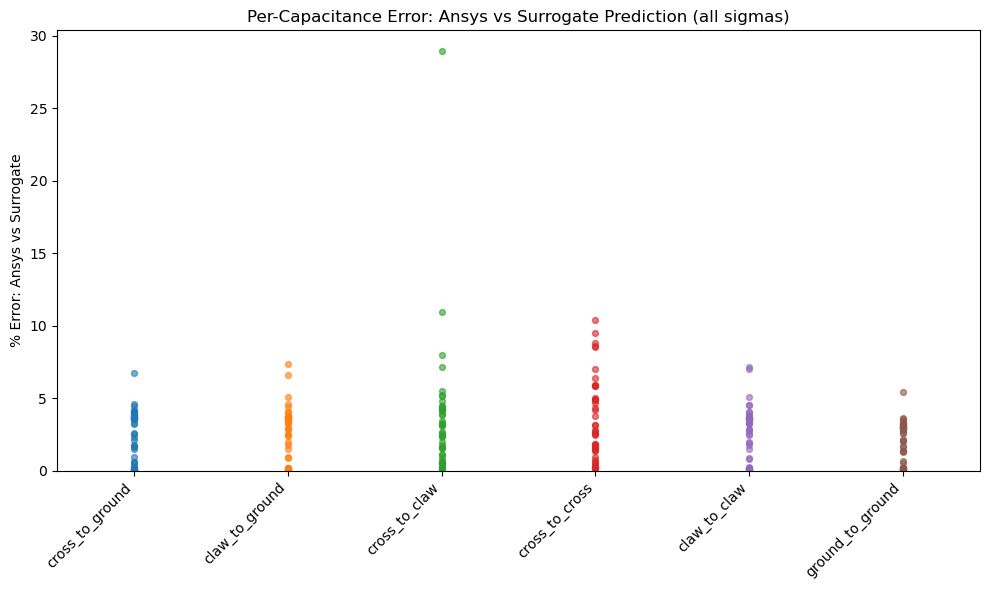

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
for j, cap in enumerate(cap_names):
    col = f'pct_ansys_vs_surrogate_{cap}'
    vals = df[col].values
    ax.scatter(np.full(len(vals), j), vals, s=18, alpha=0.6)
ax.set_xticks(range(len(cap_names)))
ax.set_xticklabels(cap_names, rotation=45, ha='right')
ax.set_ylabel('% Error: Ansys vs Surrogate')
ax.set_title('Per-Capacitance Error: Ansys vs Surrogate Prediction (all sigmas)')
ax.set_ylim(0, None)
ax.margins(y=0)
ax.set_xlim(-0.5, len(cap_names) - 0.5)
plt.tight_layout()
plt.savefig('plots/ansys_vs_surrogate_per_cap.pdf')
plt.show()

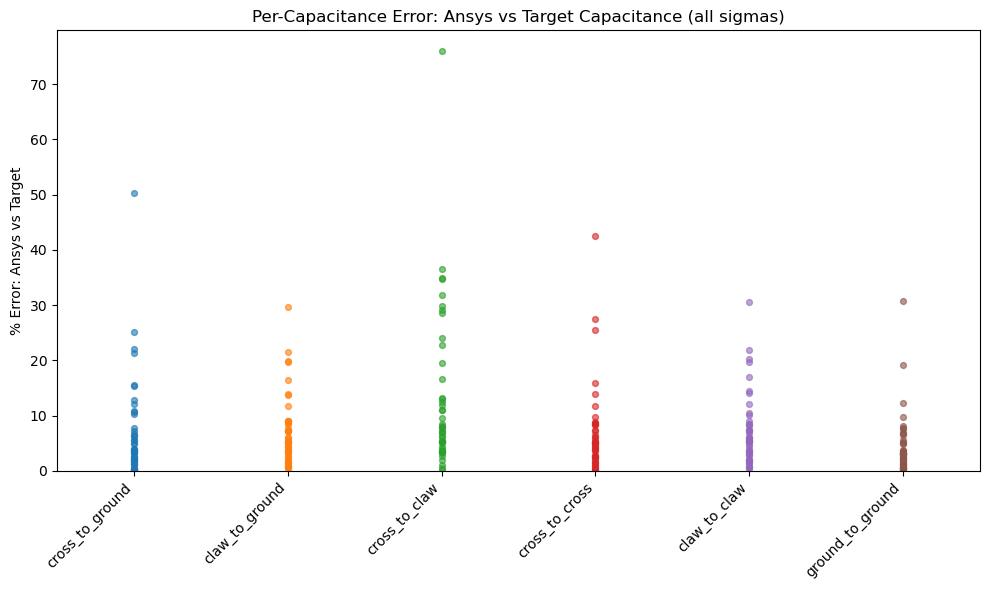

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
for j, cap in enumerate(cap_names):
    col = f'pct_ansys_vs_target_{cap}'
    vals = df[col].values
    ax.scatter(np.full(len(vals), j), vals, s=18, alpha=0.6)
ax.set_xticks(range(len(cap_names)))
ax.set_xticklabels(cap_names, rotation=45, ha='right')
ax.set_ylabel('% Error: Ansys vs Target')
ax.set_title('Per-Capacitance Error: Ansys vs Target Capacitance (all sigmas)')
ax.set_ylim(0, None)
ax.margins(y=0)
ax.set_xlim(-0.5, len(cap_names) - 0.5)
plt.tight_layout()
plt.savefig('plots/ansys_vs_target_per_cap.pdf')
plt.show()

/tmp/ipykernel_277966/1667754097.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(data_surr, labels=[f'{s}%' for s in sigmas], patch_artist=True,
/tmp/ipykernel_277966/1667754097.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(data_targ, labels=[f'{s}%' for s in sigmas], patch_artist=True,


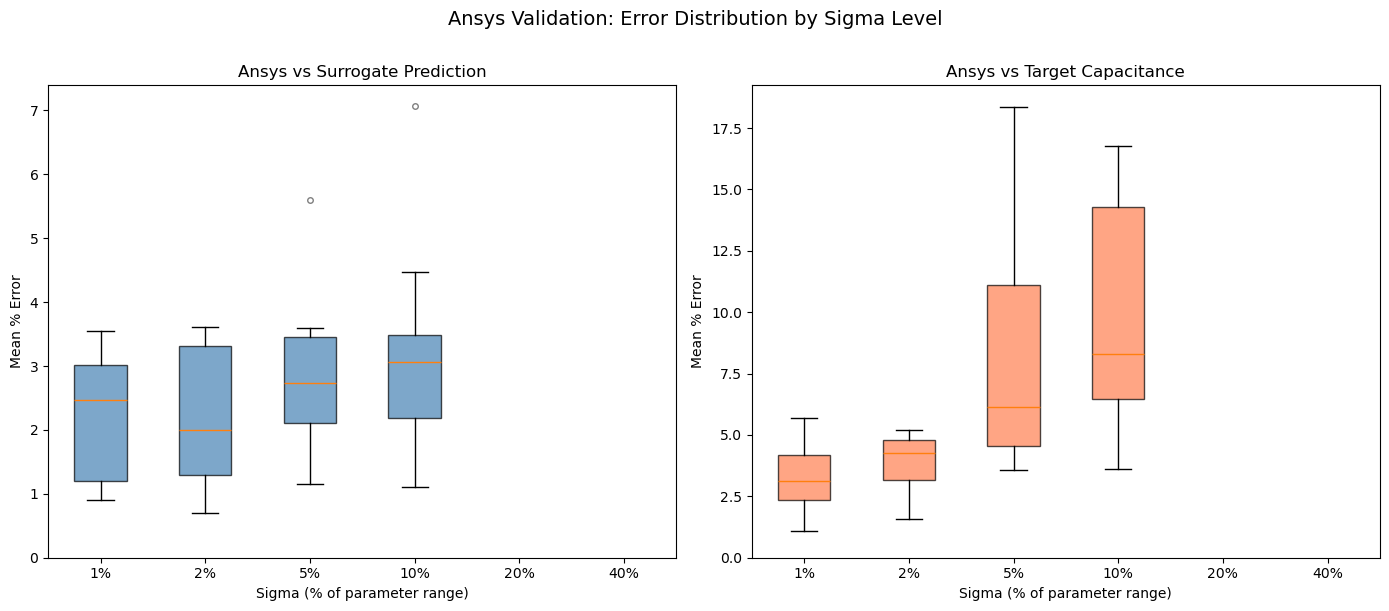

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Ansys vs Surrogate
data_surr = [df[df['sigma_for_gauss'] == s]['mean_pct_ansys_vs_surrogate'].values for s in sigmas]
bp1 = ax1.boxplot(data_surr, labels=[f'{s}%' for s in sigmas], patch_artist=True,
                  flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax1.set_xlabel('Sigma (% of parameter range)')
ax1.set_ylabel('Mean % Error')
ax1.set_title('Ansys vs Surrogate Prediction')
ax1.set_ylim(0, None)

# Ansys vs Target
data_targ = [df[df['sigma_for_gauss'] == s]['mean_pct_ansys_vs_target'].values for s in sigmas]
bp2 = ax2.boxplot(data_targ, labels=[f'{s}%' for s in sigmas], patch_artist=True,
                  flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch in bp2['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.7)
ax2.set_xlabel('Sigma (% of parameter range)')
ax2.set_ylabel('Mean % Error')
ax2.set_title('Ansys vs Target Capacitance')
ax2.set_ylim(0, None)

fig.suptitle('Ansys Validation: Error Distribution by Sigma Level', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/ansys_validation_boxplots.pdf')
plt.show()

In [25]:
print('Ansys vs Surrogate Prediction')
print(f'{"Sigma %":>10s} {"Median %":>10s} {"Mean %":>10s} {"Max %":>10s}')
print('-' * 45)
for s in sigmas:
    sub = df[df['sigma_for_gauss'] == s]['mean_pct_ansys_vs_surrogate']
    print(f'{s:10d} {sub.median():10.2f} {sub.mean():10.2f} {sub.max():10.2f}')

print()
print('Ansys vs Target Capacitance')
print(f'{"Sigma %":>10s} {"Median %":>10s} {"Mean %":>10s} {"Max %":>10s}')
print('-' * 45)
for s in sigmas:
    sub = df[df['sigma_for_gauss'] == s]['mean_pct_ansys_vs_target']
    print(f'{s:10d} {sub.median():10.2f} {sub.mean():10.2f} {sub.max():10.2f}')

Ansys vs Surrogate Prediction
   Sigma %   Median %     Mean %      Max %
---------------------------------------------
         1       2.47       2.21       3.54
         2       2.00       2.20       3.61
         5       2.74       2.87       5.60
        10       3.07       3.23       7.07
        20       3.28       4.30       9.45
        40        nan        nan        nan

Ansys vs Target Capacitance
   Sigma %   Median %     Mean %      Max %
---------------------------------------------
         1       3.14       3.32       5.67
         2       4.26       3.82       5.19
         5       6.13       8.06      18.38
        10       8.31       9.79      16.77
        20      15.88      17.93      24.16
        40        nan        nan        nan


/home/olivias/.conda/envs/cryo-modelling-env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/olivias/.conda/envs/cryo-modelling-env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


/tmp/ipykernel_277966/1667754097.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(data_surr, labels=[f'{s}%' for s in sigmas], patch_artist=True,
/tmp/ipykernel_277966/1667754097.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(data_targ, labels=[f'{s}%' for s in sigmas], patch_artist=True,


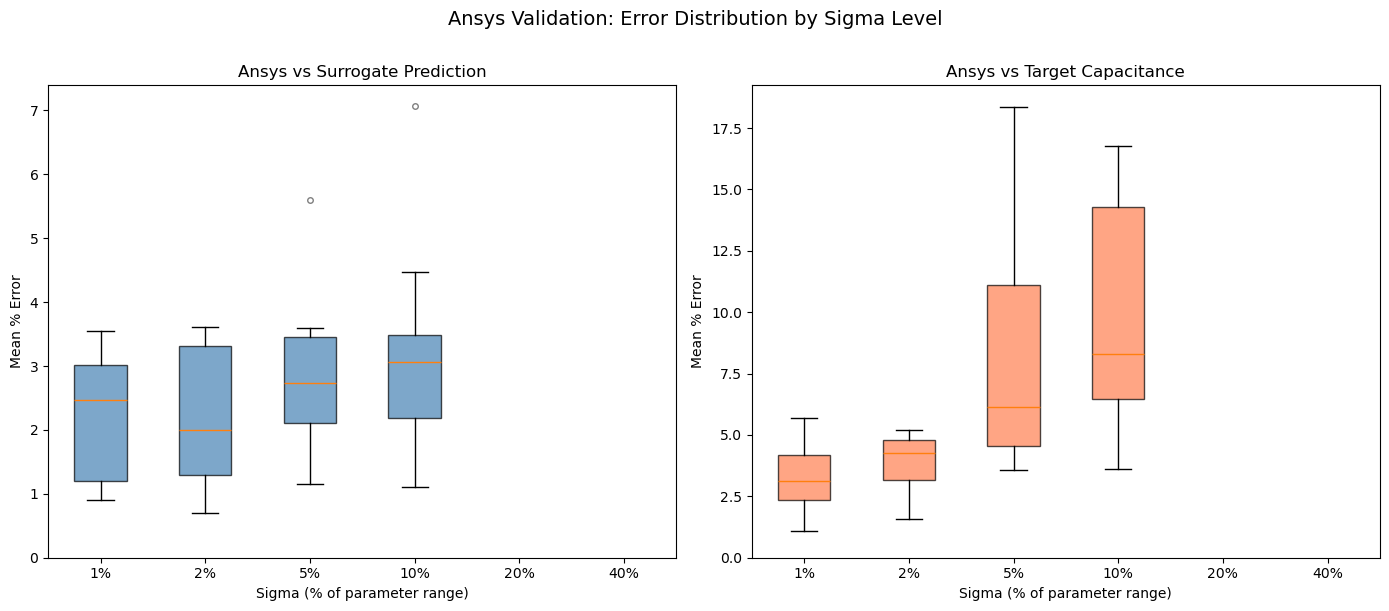

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Ansys vs Surrogate
data_surr = [df[df['sigma_for_gauss'] == s]['mean_pct_ansys_vs_surrogate'].values for s in sigmas]
bp1 = ax1.boxplot(data_surr, labels=[f'{s}%' for s in sigmas], patch_artist=True,
                  flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax1.set_xlabel('Sigma (% of parameter range)')
ax1.set_ylabel('Mean % Error')
ax1.set_title('Ansys vs Surrogate Prediction')
ax1.set_ylim(0, None)

# Ansys vs Target
data_targ = [df[df['sigma_for_gauss'] == s]['mean_pct_ansys_vs_target'].values for s in sigmas]
bp2 = ax2.boxplot(data_targ, labels=[f'{s}%' for s in sigmas], patch_artist=True,
                  flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch in bp2['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.7)
ax2.set_xlabel('Sigma (% of parameter range)')
ax2.set_ylabel('Mean % Error')
ax2.set_title('Ansys vs Target Capacitance')
ax2.set_ylim(0, None)

fig.suptitle('Ansys Validation: Error Distribution by Sigma Level', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/ansys_validation_boxplots.pdf')
plt.show()

In [27]:
df = pd.read_csv('random_candidates_for_ansys_validation-with_Ansys_results.csv')

cap_names = ['cross_to_ground', 'claw_to_ground', 'cross_to_claw',
             'cross_to_cross', 'claw_to_claw', 'ground_to_ground']
eps = 1e-15

# % error: Ansys result vs what we were aiming for (target from test set)
for cap in cap_names:
    df[f'pct_err_{cap}'] = 100 * abs(df[f'ansys_{cap}'] - df[f'target_{cap}']) / (abs(df[f'target_{cap}']) + eps)

df['mean_pct_err'] = df[[f'pct_err_{c}' for c in cap_names]].mean(axis=1)
sigmas = sorted(df['sigma_for_gauss'].unique())

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
for j, cap in enumerate(cap_names):
    vals = df[f'pct_err_{cap}'].values
    ax.scatter(np.full(len(vals), j), vals, s=18, alpha=0.6)
ax.set_xticks(range(len(cap_names)))
ax.set_xticklabels(cap_names, rotation=45, ha='right')
ax.set_ylabel('Percent Difference [%]')
ax.set_title('Ansys Simulated Capacitance vs Target Capacitance')
ax.set_ylim(0, None)
ax.margins(y=0)
ax.set_xlim(-0.5, len(cap_names) - 0.5)
plt.tight_layout()
plt.savefig('plots/ansys_vs_target_scatter.pdf')
plt.show()

# Stats
print(f'{"Cap Column":<25s} {"Median %":>10s} {"Mean %":>10s} {"Max %":>10s}')
print('-' * 55)
for cap in cap_names:
    vals = df[f'pct_err_{cap}']
    print(f'{cap:<25s} {vals.median():10.2f} {vals.mean():10.2f} {vals.max():10.2f}')
print('-' * 55)
all_vals = df['mean_pct_err']
print(f'{"All (avg per sample)":<25s} {all_vals.median():10.2f} {all_vals.mean():10.2f} {all_vals.max():10.2f}')

TypeError: unsupported operand type(s) for -: 'str' and 'float'

In [ ]:
# Ratio: how much error does the surrogate ADD vs the natural physical variation?
for cap in cap_names:
    df[f'ratio_{cap}'] = abs(df[f'ansys_{cap}'] - df[f'surrogate_pred_{cap}']) / (abs(df[f'ansys_{cap}'] - df[f'target_{cap}']) + eps)

df['mean_ratio'] = df[[f'ratio_{c}' for c in cap_names]].mean(axis=1)

print('Ratio of surrogate error to physical variation (lower = surrogate adds less noise):')
print(f'{"Sigma %":>10s} {"Median":>10s} {"Mean":>10s}')
print('-' * 35)
for s in sigmas:
    sub = df[df['sigma_for_gauss'] == s]['mean_ratio']
    print(f'{s:10d} {sub.median():10.3f} {sub.mean():10.3f}')

In [ ]:
# === How much did the noisy params change from the originals? ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('random_candidates_for_ansys_validation-with_Ansys_results.csv')

param_cols = [c for c in df.columns if c.startswith('design_options.')]
param_short = [c.replace('design_options.', '') for c in param_cols]

# Load test set to get the original seed values
X_test_unscaled_all = unscale_qiskit(np.asarray(X_test).astype('float64'))

sigmas = sorted(df['sigma_for_gauss'].unique())

# Compute % change from original seed for each param
for pc, short in zip(param_cols, param_short):
    orig_vals = []
    for _, row in df.iterrows():
        seed_idx = int(row['test_set_index_as_gauss_mean'])
        # find which position in seed_indices this corresponds to
        pos = np.where(np.array(seed_indices) == seed_idx)[0][0]
        j = param_cols.index(pc)
        orig_vals.append(seed_samples_unscaled[pos, j])
    df[f'orig_{short}'] = orig_vals
    df[f'pct_change_{short}'] = 100 * (df[pc] - df[f'orig_{short}']) / (abs(df[f'orig_{short}']) + 1e-15)

pct_change_cols = [f'pct_change_{s}' for s in param_short]

# Plot: per-sigma subplots showing % change per parameter
fig, axes = plt.subplots(1, len(sigmas), figsize=(4 * len(sigmas), 6), sharey=True)
for si, s in enumerate(sigmas):
    ax = axes[si]
    sub = df[df['sigma_for_gauss'] == s]
    for j, short in enumerate(param_short):
        vals = sub[f'pct_change_{short}'].values
        ax.scatter(np.full(len(vals), j), vals, s=18, alpha=0.6)
    ax.set_xticks(range(len(param_short)))
    ax.set_xticklabels(param_short, rotation=45, ha='right')
    ax.set_title(f'σ = {s}%')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xlim(-0.5, len(param_short) - 0.5)
    if si == 0:
        ax.set_ylabel('% Change from Original')
fig.suptitle('How Much Did the Noisy Params Change from the Originals?', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/param_pct_change_per_sigma.pdf')
plt.show()

# Print examples
print('Example parameter changes (first 3 rows per sigma):')
for s in sigmas:
    sub = df[df['sigma_for_gauss'] == s].head(3)
    print(f'\n=== σ = {s}% ===')
    for _, row in sub.iterrows():
        print(f'  Sample {int(row["sample_number"])}, Seed #{int(row["test_set_index_as_gauss_mean"])}:')
        for pc, short in zip(param_cols, param_short):
            orig = row[f'orig_{short}']
            noisy = row[pc]
            pct = row[f'pct_change_{short}']
            print(f'    {short:40s}  orig={orig:.6f}  noisy={noisy:.6f}  change={pct:+.2f}%')